# Análisis exploratorio de datos de GDELT

In [57]:
from google.cloud import bigquery

client = bigquery.Client(project="prueba-505900")
Limit=10000
PartionTime_init = "2026-08-16"
PartionTime_end = "2026-08-17"

query = f"""
SELECT
    GLOBALEVENTID,
    SQLDATE,
    Actor1Name,
    Actor2Name,

    EventCode,
    GoldsteinScale,
    AvgTone,
    NumMentions,

    Actor1Geo_Type,
    Actor1Geo_FullName,
    Actor1Geo_CountryCode,
    Actor1Geo_Lat,
    Actor1Geo_Long,

    Actor2Geo_Type,
    Actor2Geo_FullName,
    Actor2Geo_CountryCode,
    Actor2Geo_Lat,
    Actor2Geo_Long,

    ActionGeo_Type,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    ActionGeo_Lat,
    ActionGeo_Long

FROM `gdelt-bq.gdeltv2.events_partitioned`

WHERE _PARTITIONTIME >= TIMESTAMP('{PartionTime_init}')
  AND _PARTITIONTIME < TIMESTAMP('{PartionTime_end}')

ORDER BY GLOBALEVENTID

LIMIT {Limit}
"""



df = client.query(query).to_dataframe()
df

c:\Users\alex2\OneDrive\Documentos\Repositorio Github\Portafolio\ETL_GDELT\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,GLOBALEVENTID,SQLDATE,Actor1Name,Actor2Name,EventCode,GoldsteinScale,AvgTone,NumMentions,Actor1Geo_Type,Actor1Geo_FullName,...,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_Lat,Actor2Geo_Long,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long
0,1318458447,20260816,NaN,BRISBANE,042,1.9,-0.373832,11,0,NaN,...,4,"Brisbane, Queensland, Australia",AS,-27.5000,153.01700,4,"Brisbane, Queensland, Australia",AS,-27.5000,153.01700
1,1318458448,20260816,NaN,VICTORIA,042,1.9,2.768903,5,0,NaN,...,4,"Melbourne, Victoria, Australia",AS,-37.8167,144.96700,4,"Melbourne, Victoria, Australia",AS,-37.8167,144.96700
2,1318458449,20260816,NaN,AUSTRALIA,042,1.9,1.368613,2,0,NaN,...,4,"Perth, Western Australia, Australia",AS,-31.9333,115.83300,4,"Perth, Western Australia, Australia",AS,-31.9333,115.83300
3,1318458450,20260816,NaN,AUSTRALIA,046,7.0,1.035503,6,0,NaN,...,4,"Spring Creek, Queensland, Australia",AS,-23.5833,150.18300,4,"Loomberah, New South Wales, Australia",AS,-31.1833,151.00000
4,1318458451,20260816,NaN,AUSTRALIA,190,-10.0,-8.685446,8,0,NaN,...,1,Australia,AS,-25.0000,135.00000,1,Australia,AS,-25.0000,135.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1318468789,20260816,NIGER,ALGERIA,040,1.0,-0.716612,8,4,"Niamey, Niamey, Niger",...,4,"Algiers, Alger, Algeria",AG,36.7631,3.05056,4,"Niamey, Niamey, Niger",NG,13.5167,2.11667
9996,1318468790,20260816,NIGER,ALGERIA,040,1.0,-0.716612,2,4,"Niamey, Niamey, Niger",...,4,"Algiers, Alger, Algeria",AG,36.7631,3.05056,4,"Algiers, Alger, Algeria",AG,36.7631,3.05056
9997,1318468791,20260816,NIGER,NaN,051,3.4,2.954048,4,4,"Agadez, Agadez, Niger",...,0,NaN,NaN,NaN,NaN,4,"Agadez, Agadez, Niger",NG,16.9733,7.99111
9998,1318468792,20260816,NORTH KOREAN,UKRAINE,062,7.4,0.000000,2,4,"Pyongyang, P'yongyang-si, North Korea",...,1,Ukraine,UP,49.0000,32.00000,4,"Pyongyang, P'yongyang-si, North Korea",KN,39.0194,125.75500


De acuerdo a la documentación las columnas con Action son las mas adecuadas para situarlas en un mapa, y debido a que son las que tienen menor número de valores nulos se eligiran esas para las consultas.Avgtone nos indica el tono de la noticia, su rango va de -100 a 100, donde 0 sería una noticia neutra. Goldensteinscale caputra el potenial impacto de cada tipo de evento en la estabilidad del país.



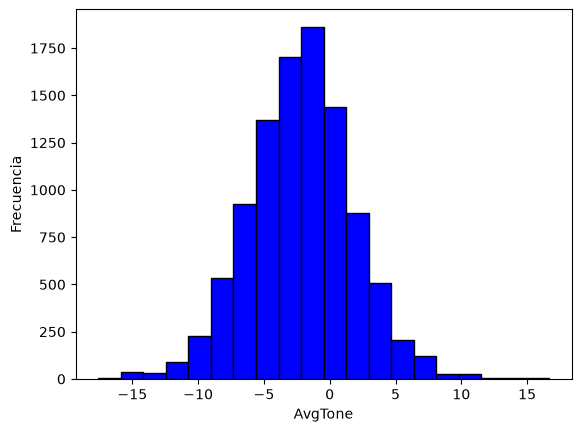

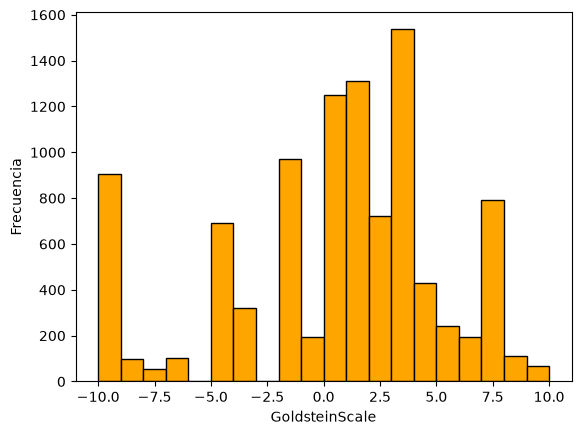

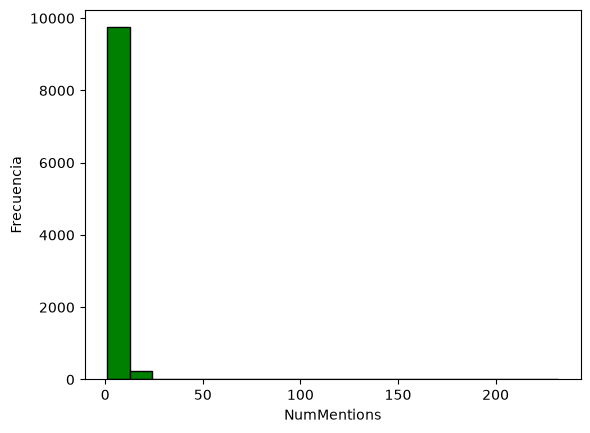

In [ ]:
# Generar histograma de la columna "AvgTone"
import matplotlib.pyplot as plt
bins = 20  # Número de bins para el histograma
plt.hist(df["AvgTone"].dropna(), edgecolor='black',bins=bins,color='blue')
plt.xlabel("AvgTone")
plt.ylabel("Frecuencia")
plt.show()

# Histograma de la columna GoldsteinScale
plt.hist(df["GoldsteinScale"].dropna(), edgecolor='black',bins=bins,color='orange')
plt.xlabel("GoldsteinScale")
plt.ylabel("Frecuencia")
plt.show()

# Histograma de la columna NumMentions
plt.hist(df["NumMentions"].dropna(), edgecolor='black',bins=bins,color='green')
plt.xlabel("NumMentions")
plt.ylabel("Frecuencia")
plt.show()

Se nota claramente que numero de menciones tiene datos a nomalos pues unos pocos llegan arriba de  menciones

In [64]:
df["NumMentions"].describe()

count     10000.0
mean       5.9841
std      4.942741
min           1.0
25%           2.0
50%           5.0
75%          10.0
max         232.0
Name: NumMentions, dtype: Float64

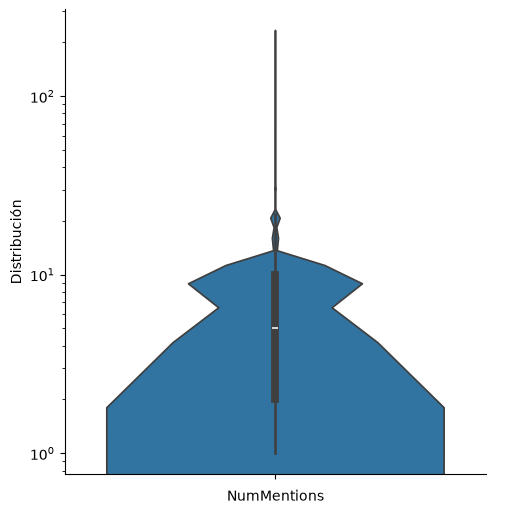

In [ ]:
# violin plot of the column "NumMentions"
import seaborn as sns

sns.catplot(data=df, y="NumMentions", kind="violin")
plt.yscale("log") # Escala logaritmica para la visualización
plt.xlabel("NumMentions")
plt.ylabel("Distribución")
plt.show()


Con esto confirmamos que los datos estan, en su mayoria, en un numero menor a 10 en lo que respecta a Nummentions. 

Para obtener los eventos mas representativos y que sean representativos

In [104]:
# Leer txt 
import pandas as pd
df_txt_eventscode = pd.read_csv("CAMEO.eventcodes.txt", sep='\t')
df_txt_eventscode.head()
df_txt_eventscode["CAMEOEVENTCODE"] = df_txt_eventscode["CAMEOEVENTCODE"].astype(str).str.zfill(4)  # Asegurarse de que los códigos tengan 4 dígitos
df_txt_eventscode = df_txt_eventscode.rename(columns={
    "CAMEOEVENTCODE": "EventCode"
})
df_txt_eventscode

,EventCode,EVENTDESCRIPTION
0,0001,MAKE PUBLIC STATEMENT
1,0010,"Make statement, not specified below"
2,0011,Decline comment
3,0012,Make pessimistic comment
4,0013,Make optimistic comment
...,...,...
305,0202,Engage in mass killings
306,0203,Engage in ethnic cleansing
307,0204,"Use weapons of mass destruction, not specified..."
308,2041,"Use chemical, biological, or radiologicalweapons"


In [105]:
df_event_counts = (
    df["EventCode"]
    .value_counts()
    .reset_index(name="Count")
    .merge(
        df_txt_eventscode,
        on="EventCode",
        how="left"
    )
)
df_event_counts

,EventCode,Count,EVENTDESCRIPTION
0,0010,940,"Make statement, not specified below"
1,0010,940,DEMAND
2,0042,757,Make a visit
3,0043,716,Host a visit
4,0020,703,"Appeal, not specified below"
...,...,...,...
159,1233,1,Reject request for rights
160,0092,1,Investigate human rights abuses
161,0171,1,"Seize or damage property, not specified below"
162,1043,1,Demand rights


In [109]:
# De manera similar con los paises
df_txt_countrycode = pd.read_csv("FIPS.country.txt", sep='\t',header=None, names=["ActionGeo_CountryCode", "CountryName"])
df_txt_countrycode

,ActionGeo_CountryCode,CountryName
0,AF,Afghanistan
1,AX,Akrotiri Sovereign Base Area
2,AL,Albania
3,AG,Algeria
4,AQ,American Samoa
...,...,...
269,WE,West Bank
270,WI,Western Sahara
271,YM,Yemen
272,ZA,Zambia


In [116]:
pip install jupyter

Note: you may need to restart the kernel to use updated packages.


In [113]:
# Unir a conteo de paises mas frecuentes    
df_country_counts = (
    df["ActionGeo_CountryCode"]
    .value_counts()
    .reset_index(name="Count")
    .merge(
        df_txt_countrycode,
        on="ActionGeo_CountryCode",
        how="left"
    )
)
df_country_counts.head(15)

,ActionGeo_CountryCode,Count,CountryName
0,US,2711,United States
1,IS,562,Israel
2,NI,466,Nigeria
3,AS,301,Australia
4,IR,282,Iran
5,IN,275,India
6,RS,262,Russia
7,UK,250,United Kingdom
8,CO,242,Colombia
9,MX,224,Mexico


In [123]:
import folium

m = folium.Map(
    location=[20, 0],
    zoom_start=2
)

folium.Choropleth(
    geo_data="https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json",
    data=df_country_counts,
    columns=["CountryName", "Count"],
    key_on="feature.id",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Número de eventos"
).add_to(m)

m.save("mapa_gdelt.html")

In [120]:
import requests

url = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json"

geojson = requests.get(url).json()

In [ ]:
heat_data = (
    df[["ActionGeo_Lat", "ActionGeo_Long"]]
    .dropna()
    .values
    .tolist()
)


NameError: name 'head_data' is not defined